# 准备数据

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression #线性回归模型
from sklearn.preprocessing import PolynomialFeatures #多项式特征生成器
from sklearn.model_selection import train_test_split # 划分数据集
from sklearn.metrics import mean_squared_error #导入均方误差
plt.rcParams["font.sans-serif"]=["SimHei"] # 设置matplotlib中文字体
plt.rcParams["axes.unicode_minus"]=False


# 生成数据

In [3]:
x=np.linspace(-np.pi,np.pi,num=300).reshape(-1,1)
x.shape

(300, 1)

In [4]:
np.random.seed(42)
y=np.sin(x)+np.random.uniform(-0.8,0.8,300).reshape(-1,1)
y.shape

(300, 1)

# 画三个空图

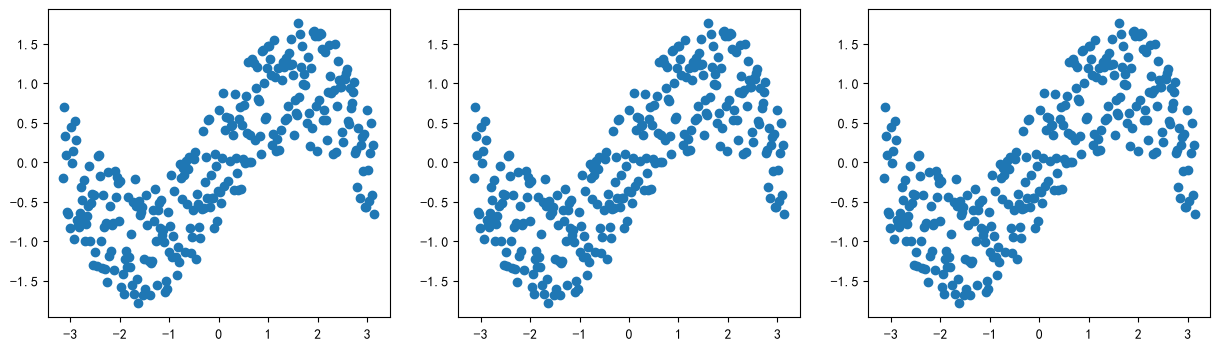

In [5]:
fig,axs=plt.subplots(1,3,figsize=(15,4))
axs[0].scatter(x,y)
axs[1].scatter(x,y)
axs[2].scatter(x,y)

In [6]:
# 数据集划分
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
print(train_x.shape,test_x.shape)
print(train_y.shape,test_y.shape)

(240, 1) (60, 1)
(240, 1) (60, 1)


In [8]:
# 定义模型
model=LinearRegression()

In [9]:
# 训练模型 欠拟合
model.fit(train_x,train_y)
print(model.coef_,model.intercept_)# W 和 b

[[0.32123045]] [-0.01092541]


In [10]:
# 模型评估（看损失值）
train_loss=mean_squared_error(train_y,model.predict(train_x))
test_loss=mean_squared_error(test_y,model.predict(test_x))
print(f"欠拟合：train误差:{train_loss},test误差:{test_loss}")

欠拟合：train误差:0.41619330240336094,test误差:0.4969293406325748


In [11]:
# 绘制曲线
axs[0].plot(x,model.predict(x),c='r')
axs[0].text(-3,1,f"训练集均方误差:{train_loss:.4f}")
axs[0].text(-3,1.3,f"测试集均方误差:{test_loss:.4f}")
score=model.score(test_x,test_y) #R^2决定系数
print(f"测试集 R^2 :{score}")
# 绘图全部写完之后，必须加这一行
plt.show()

测试集 R^2 :0.4083172312995015


In [12]:
# 恰好拟合
# 特征工程

poly5=PolynomialFeatures(degree=5)
train_x2=poly5.fit_transform(train_x)# 转换规则，转换数据得到新的训练数据
test_x2=poly5.transform(test_x)
print(train_x2.shape,test_x2.shape)

(240, 6) (60, 6)


In [13]:
# 5.训练模型
model.fit(train_x2,train_y)
print(model.coef_,model.intercept_)

[[ 0.00000000e+00  9.01647832e-01  5.14268401e-02 -9.86516921e-02
  -6.53342069e-03  2.48828109e-04]] [-0.05139185]


In [14]:
# 模型评估
train_loss=mean_squared_error(train_y,model.predict(train_x2))
test_loss=mean_squared_error(test_y,model.predict(test_x2))
print(f"恰好过拟合:训练误差{train_loss},测试误差:{test_loss}")

恰好过拟合:训练误差0.21685339244617083,测试误差:0.21138711465479557


In [15]:
# 7.绘制曲线
axs[1].plot(x, model.predict(poly5.transform(x)), c='r')
axs[1].text(-3, 1, f"测试集均方误差：{test_loss:.4f}")
axs[1].text(-3, 1.3, f"训练集均方误差：{train_loss:.4f}")
print(model.score(test_x2, test_y))

0.7483060406388081


In [17]:
# 过拟合阶段
poly20=PolynomialFeatures(degree=20)
train_x3=poly20.fit_transform(train_x)
test_x3=poly20.transform(test_x)
print(train_x3.shape,test_x3.shape)

(240, 21) (60, 21)


In [19]:
# 训练模型
model.fit(train_x3,train_y)
print(model.coef_,model.intercept_)

[[ 0.00000000e+00  6.89917801e-01  3.00283589e-01  1.21294222e+00
  -7.03373663e-01 -2.01657995e+00  7.77166606e-01  1.32479957e+00
  -5.75396135e-01 -4.36947757e-01  2.78684124e-01  7.41708533e-02
  -8.28744895e-02 -5.50162874e-03  1.48082920e-02 -4.66597989e-05
  -1.54619207e-03  2.99103236e-05  8.68168822e-05 -1.20667471e-06
  -2.02310991e-06]] [-0.04314273]


In [21]:
# 模型评估 看损失
train_loss = mean_squared_error(train_y,model.predict(train_x3))
test_loss=mean_squared_error(test_y,model.predict(test_x3))
print(f"过拟合的训练误差:{train_loss},测试误差{test_loss}")

过拟合的训练误差:0.2026897957740095,测试误差0.25576861366645237


In [25]:
# 绘制曲线
axs[2].plot(x,model.predict(poly20.transform(x)),c='r')
axs[2].text(-3,1,f"训练集均方误差:{train_loss:.4f}")
axs[2].text(-3,1.3,f"测试集均方误差:{test_loss:.4f}")
print(model.score(test_x3,test_y))

0.6954619719410982


In [26]:
plt.show()

# 整理在一个cell

x.shape: (300, 1)
y.shape: (300, 1)
train_x.shape, test_x.shape: (240, 1) (60, 1)
train_y.shape, test_y.shape: (240, 1) (60, 1)
W系数, b偏置： [[0.32123045]] [-0.01092541]
欠拟合：train误差:0.41619330240336094, test误差:0.4969293406325748，R^2:0.4083172312995015
poly5转换后 train_x2.shape, test_x2.shape： (240, 6) (60, 6)
poly5 W系数, b偏置： [[ 0.00000000e+00  9.01647832e-01  5.14268401e-02 -9.86516921e-02
  -6.53342069e-03  2.48828109e-04]] [-0.05139185]
恰好拟合:训练误差0.21685339244617083,测试误差:0.21138711465479557，R^2:0.7483060406388081
poly20转换后 train_x3.shape, test_x3.shape： (240, 21) (60, 21)
poly20 W系数, b偏置： [[ 0.00000000e+00  6.89917801e-01  3.00283589e-01  1.21294222e+00
  -7.03373663e-01 -2.01657995e+00  7.77166606e-01  1.32479957e+00
  -5.75396135e-01 -4.36947757e-01  2.78684124e-01  7.41708533e-02
  -8.28744895e-02 -5.50162874e-03  1.48082920e-02 -4.66597989e-05
  -1.54619207e-03  2.99103236e-05  8.68168822e-05 -1.20667471e-06
  -2.02310991e-06]] [-0.04314273]
过拟合的训练误差:0.2026897957740095,测试误差0.2557686136

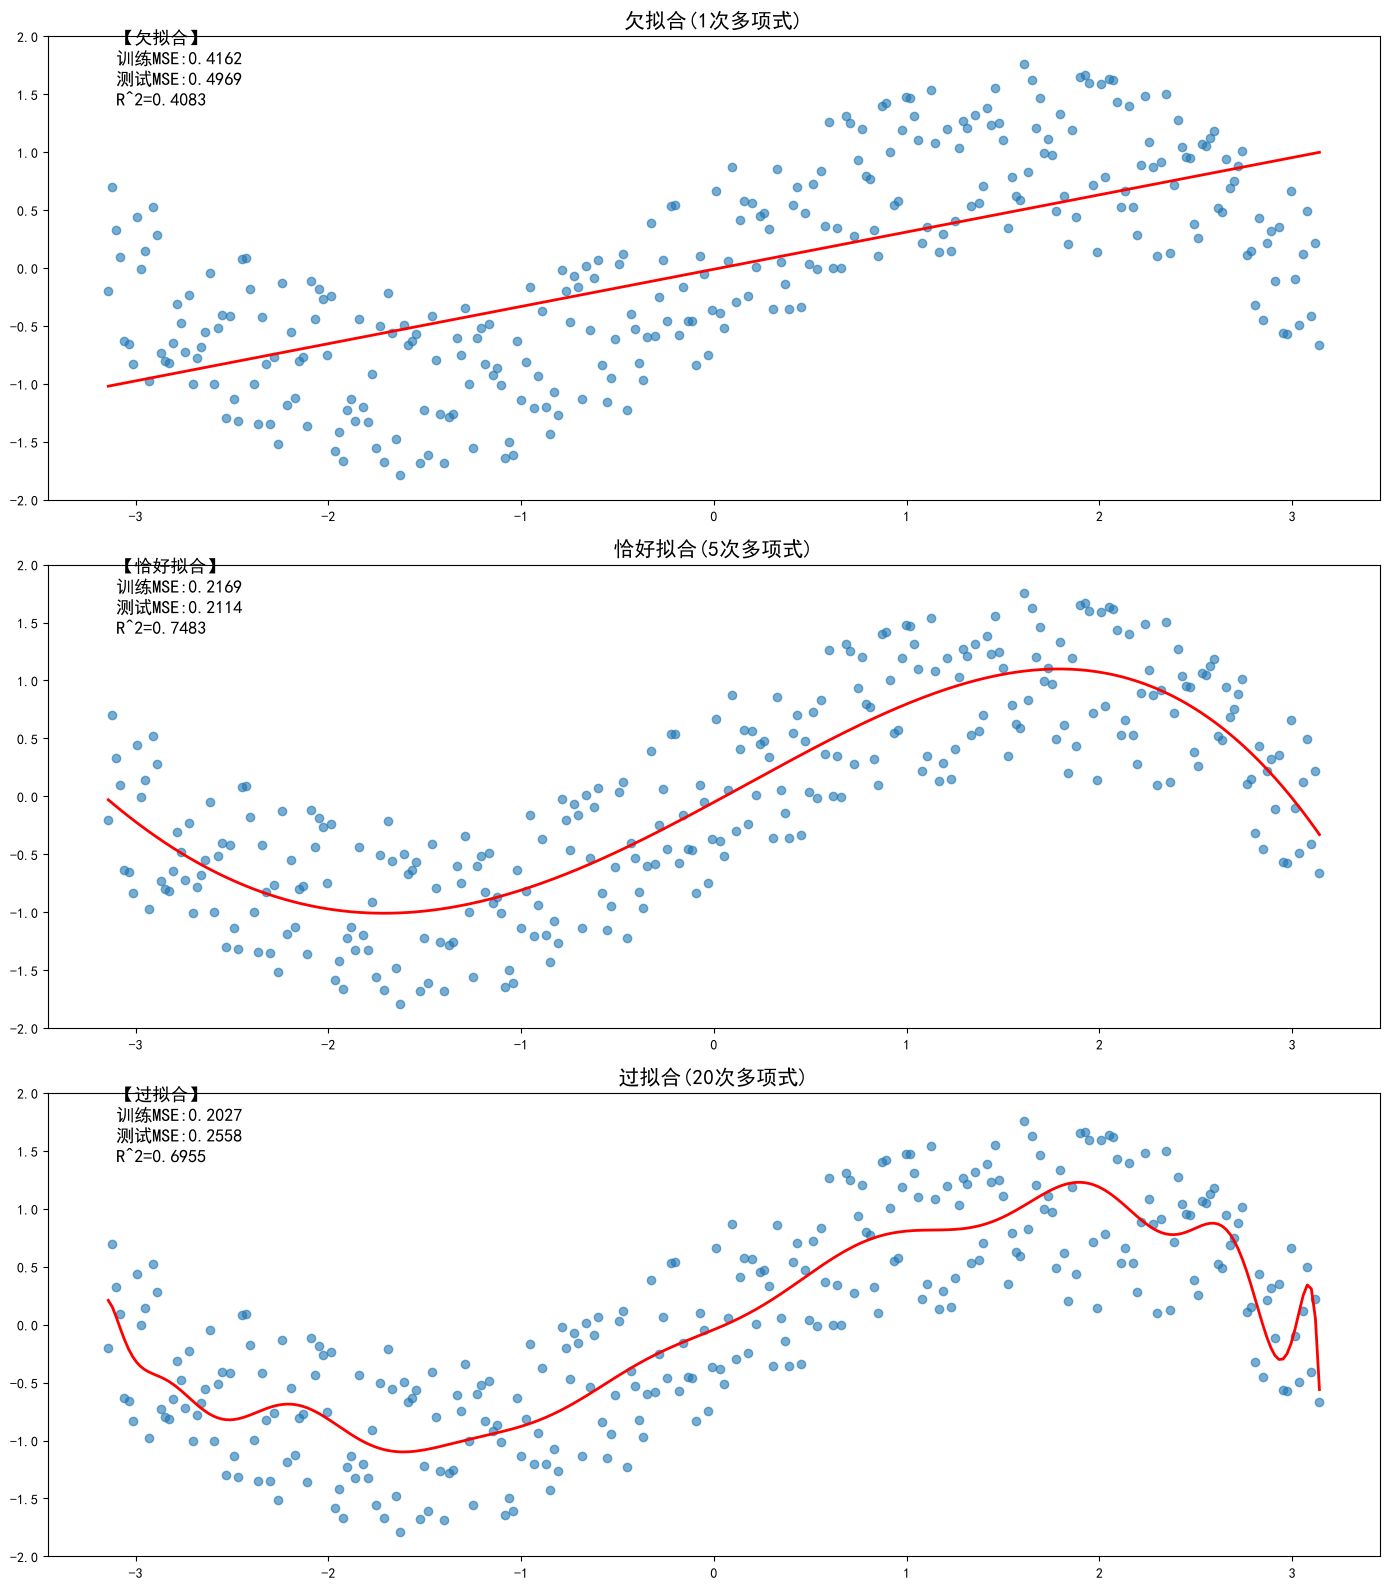

In [29]:
# ===================== 准备数据 导入库 =====================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression  # 线性回归模型
from sklearn.preprocessing import PolynomialFeatures  # 多项式特征生成器
from sklearn.model_selection import train_test_split  # 划分数据集
from sklearn.metrics import mean_squared_error  # 导入均方误差

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 设置matplotlib中文字体
plt.rcParams["axes.unicode_minus"] = False

# ===================== 生成数据 =====================
# 在-π ~ π之间生成300个点，reshape转为二维 (样本数,特征数)
x = np.linspace(-np.pi, np.pi, num=300).reshape(-1, 1)
print("x.shape:", x.shape)

np.random.seed(42)  # 设置随机种子，保证每次运行结果一致
y = np.sin(x) + np.random.uniform(-0.8, 0.8, 300).reshape(-1, 1)
print("y.shape:", y.shape)

# ===================== 创建画布：3行1列 竖向排布 =====================
fig, axs = plt.subplots(3, 1, figsize=(14, 16))
axs[0].scatter(x, y, alpha=0.6)
axs[1].scatter(x, y, alpha=0.6)
axs[2].scatter(x, y, alpha=0.6)

# ===================== 数据集划分：训练集、测试集 =====================
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42)
print("train_x.shape, test_x.shape:", train_x.shape, test_x.shape)
print("train_y.shape, test_y.shape:", train_y.shape, test_y.shape)

# ===================== 1、欠拟合：普通线性回归 =====================
model = LinearRegression()
model.fit(train_x, train_y)
print("W系数, b偏置：", model.coef_, model.intercept_)

train_loss = mean_squared_error(train_y, model.predict(train_x))
test_loss = mean_squared_error(test_y, model.predict(test_x))
score_under = model.score(test_x, test_y)
print(f"欠拟合：train误差:{train_loss}, test误差:{test_loss}，R^2:{score_under}")

axs[0].plot(x, model.predict(x), c='r', lw=2)
info_text_under = (f"【欠拟合】\n"
                   f"训练MSE:{train_loss:.4f}\n"
                   f"测试MSE:{test_loss:.4f}\n"
                   f"R^2={score_under:.4f}")
axs[0].text(-3.1, 1.4, info_text_under, fontsize=13)
axs[0].set_title("欠拟合(1次多项式)", fontsize=15)
axs[0].set_ylim(-2, 2)

# ===================== 2、恰好拟合：5次多项式 =====================
poly5 = PolynomialFeatures(degree=5)
train_x2 = poly5.fit_transform(train_x)
test_x2 = poly5.transform(test_x)
print("poly5转换后 train_x2.shape, test_x2.shape：", train_x2.shape, test_x2.shape)

model.fit(train_x2, train_y)
print("poly5 W系数, b偏置：", model.coef_, model.intercept_)

train_loss5 = mean_squared_error(train_y, model.predict(train_x2))
test_loss5 = mean_squared_error(test_y, model.predict(test_x2))
score_good = model.score(test_x2, test_y)
print(f"恰好拟合:训练误差{train_loss5},测试误差:{test_loss5}，R^2:{score_good}")

axs[1].plot(x, model.predict(poly5.transform(x)), c='r', lw=2)
info_text_good = (f"【恰好拟合】\n"
                  f"训练MSE:{train_loss5:.4f}\n"
                  f"测试MSE:{test_loss5:.4f}\n"
                  f"R^2={score_good:.4f}")
axs[1].text(-3.1, 1.4, info_text_good, fontsize=13)
axs[1].set_title("恰好拟合(5次多项式)", fontsize=15)
axs[1].set_ylim(-2, 2)

# ===================== 3、过拟合：20次高次多项式 =====================
poly20 = PolynomialFeatures(degree=20)
train_x3 = poly20.fit_transform(train_x)
test_x3 = poly20.transform(test_x)
print("poly20转换后 train_x3.shape, test_x3.shape：", train_x3.shape, test_x3.shape)

model.fit(train_x3, train_y)
print("poly20 W系数, b偏置：", model.coef_, model.intercept_)

train_loss20 = mean_squared_error(train_y, model.predict(train_x3))
test_loss20 = mean_squared_error(test_y, model.predict(test_x3))
score_over = model.score(test_x3, test_y)
print(f"过拟合的训练误差:{train_loss20},测试误差{test_loss20}，R^2:{score_over}")

axs[2].plot(x, model.predict(poly20.transform(x)), c='r', lw=2)
info_text_over = (f"【过拟合】\n"
                  f"训练MSE:{train_loss20:.4f}\n"
                  f"测试MSE:{test_loss20:.4f}\n"
                  f"R^2={score_over:.4f}")
axs[2].text(-3.1, 1.4, info_text_over, fontsize=13)
axs[2].set_title("过拟合(20次多项式)", fontsize=15)
axs[2].set_ylim(-2, 2)


plt.tight_layout()
plt.show()